In [ ]:
!pip install openaq
!pip install openmeteo-requests

In [ ]:
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderServiceError

def get_coordinates_from_location(location_name: str) -> tuple:
    """
    Convert a human-readable location string into (latitude, longitude).
    Accepts city names, addresses, landmarks, etc.

    Parameters:
        location_name (str): e.g. "Delhi", "New York", "Paris, France"

    Returns:
        tuple: (latitude, longitude) as floats
    """
    geolocator = Nominatim(user_agent="aq_forecaster_v1")
    try:
        location = geolocator.geocode(location_name, timeout=10)
        if location is None:
            raise ValueError(
                f"❌ Could not find coordinates for '{location_name}'. "
                "Try a more specific name, e.g. 'Mumbai, India' or 'London, UK'."
            )
        print(f"📍 Location resolved: {location.address}")
        print(f"   Coordinates → Latitude: {location.latitude:.4f}, Longitude: {location.longitude:.4f}")
        return (location.latitude, location.longitude)
    except GeocoderTimedOut:
        raise TimeoutError("⏱ Geocoding service timed out. Check your internet connection and retry.")
    except GeocoderServiceError as e:
        raise RuntimeError(f"🌐 Geocoding service error: {e}")

In [ ]:
def get_date_range(start_date: str = None, end_date: str = None) -> tuple:
    """
    Resolve and validate the date range for data fetching.
    If not provided, defaults to the past 3 months up to today.

    Parameters:
        start_date (str | None): 'YYYY-MM-DD' format. If None, auto-set.
        end_date   (str | None): 'YYYY-MM-DD' format. If None, defaults to today.

    Returns:
        tuple: (start_date_str, end_date_str, start_dt_iso, end_dt_iso)
               where ISO strings include timezone offset for OpenAQ
    """
    today = datetime.utcnow().date()

    if end_date is None:
        end_dt = today
        print(f"ℹ️  No end date given — defaulting to today: {end_dt}")
    else:
        try:
            end_dt = datetime.strptime(end_date, "%Y-%m-%d").date()
        except ValueError:
            raise ValueError(f"❌ Invalid end_date format: '{end_date}'. Use YYYY-MM-DD.")

    if start_date is None:
        start_dt = end_dt - relativedelta(months=3)
        print(f"ℹ️  No start date given — defaulting to 3 months back: {start_dt}")
    else:
        try:
            start_dt = datetime.strptime(start_date, "%Y-%m-%d").date()
        except ValueError:
            raise ValueError(f"❌ Invalid start_date format: '{start_date}'. Use YYYY-MM-DD.")

    if start_dt >= end_dt:
        raise ValueError(
            f"❌ start_date ({start_dt}) must be before end_date ({end_dt})."
        )

    # Plain strings for Open-Meteo (YYYY-MM-DD)
    start_str = str(start_dt)
    end_str   = str(end_dt)

    # ISO-8601 strings with UTC offset for OpenAQ
    start_iso = f"{start_dt}T00:00:00+00:00"
    end_iso   = f"{end_dt}T23:59:59+00:00"

    print(f"📅 Training date range: {start_str}  →  {end_str}")
    return start_str, end_str, start_iso, end_iso

In [ ]:
coords = get_coordinates_from_location("Delhi")

# Resolve date range
start_date_str, end_date_str, start_iso, end_iso = get_date_range(
    None, None
)


📍 Location resolved: New Delhi, Delhi, India
   Coordinates → Latitude: 28.6139, Longitude: 77.2090
ℹ️  No end date given — defaulting to today: 2026-02-16
ℹ️  No start date given — defaulting to 3 months back: 2025-11-16
📅 Training date range: 2025-11-16  →  2026-02-16


/tmp/ipython-input-1312749433.py:14: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  today = datetime.utcnow().date()


In [ ]:
import pandas as pd
import time
import re
from pandas import json_normalize
from openaq import OpenAQ, RateLimitError

def fetch_air_quality_data(api_key: str, coordinates: tuple, radius: int = 10000,
                           limit: int = 100, measurement_limit: int = 200,
                           max_sensors: int = 30,
                           start_date: str = None, end_date: str = None,
                           timezone: str = "UTC"):
    """
    Fetch air quality measurements from OpenAQ for given coordinates.
    Handles rate limits gracefully, supports date constraints, and normalizes timezone.
    """
    client = OpenAQ(api_key=api_key)

    locations = client.locations.list(
        coordinates=coordinates,
        radius=radius,
        limit=limit
    )
    data = locations.dict()
    df = json_normalize(data['results'])

    sensor_list = df['sensors']
    ids = [item['id'] for sublist in sensor_list for item in sublist][:max_sensors]

    raw_data = []
    for sensor_id in ids:
        try:
            measurements = client.measurements.list(
                sensors_id=sensor_id,
                limit=measurement_limit,
                datetime_from=start_date,
                datetime_to=end_date
            )
            for m in measurements.results:
                entry = (
                    f"Time: {m.period.datetime_from.local} | "
                    f"Value: {m.value} {m.parameter.units},{m.parameter.name}"
                )
                raw_data.append(entry)
        except RateLimitError:
            print("⚠️  Rate limit hit — waiting 40 s before retry...")
            time.sleep(40)
            continue

    parsed = []
    for line in raw_data:
        time_part, value_part = line.split(" | ")
        t = time_part.replace("Time: ", "").strip()
        dt = pd.to_datetime(t)
        if dt.tzinfo is None:
            dt = dt.tz_localize("UTC")
        dt = dt.tz_convert("Asia/Kolkata").tz_localize(None)

        value_str = value_part.replace("Value: ", "").strip()
        val, pollutant = value_str.split(",")
        numeric_val = re.findall(r"[-+]?\d*\.\d+|\d+", val)
        if not numeric_val:
            continue
        parsed.append([dt, float(numeric_val[0]), pollutant])

    return pd.DataFrame(parsed, columns=["time", "value", "pollutant"])


In [ ]:
api_key = "deec2a1812fd31dbd1b2b6f4334a3be31010d81450757f8edf0eac430ae5f420"


df = fetch_air_quality_data(
    api_key, coords,
    start_date=start_iso,
    end_date=end_iso
)

print(df.head())


                 time  value pollutant
0 2025-11-16 05:30:00   0.89        co
1 2025-11-16 05:45:00   0.87        co
2 2025-11-16 06:00:00   0.86        co
3 2025-11-16 06:15:00   0.85        co
4 2025-11-16 06:30:00   0.86        co


In [ ]:
import openmeteo_requests

def fetch_historical_weather(latitude: float, longitude: float,
                             start_date: str, end_date: str,
                             hourly_vars: list = [
                                 "temperature_2m", "relative_humidity_2m",
                                 "wind_speed_10m", "wind_direction_10m"
                             ]):
    """
    Fetch historical hourly weather from the Open-Meteo Archive API.
    """
    client = openmeteo_requests.Client()
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": hourly_vars,
        "timezone": "UTC"
    }
    responses = client.weather_api(
        "https://archive-api.open-meteo.com/v1/archive", params=params
    )
    response = responses[0]
    hourly = response.Hourly()
    hourly_time = pd.date_range(
        start=pd.to_datetime(hourly.Time(), unit="s"),
        end=pd.to_datetime(hourly.TimeEnd(), unit="s"),
        freq=pd.Timedelta(seconds=hourly.Interval()),
        inclusive="left"
    )
    hourly_data = {var: hourly.Variables(i).ValuesAsNumpy() for i, var in enumerate(hourly_vars)}
    return pd.DataFrame(hourly_data, index=hourly_time)




In [ ]:
coords = (28.7041, 77.1025)  # Delhi
weather_df = fetch_historical_weather(
    coords[0], coords[1],
    start_date=start_date_str,
    end_date=end_date_str
)

print(weather_df.head())

                     temperature_2m  relative_humidity_2m  wind_speed_10m  \
2025-11-16 00:00:00           10.80             87.753510        4.452954   
2025-11-16 01:00:00           10.55             87.434517        3.964089   
2025-11-16 02:00:00           11.35             82.073250        5.402999   
2025-11-16 03:00:00           13.75             70.359840        4.683460   
2025-11-16 04:00:00           17.35             58.179741        3.600000   

                     wind_direction_10m  
2025-11-16 00:00:00          284.036255  
2025-11-16 01:00:00          267.397491  
2025-11-16 02:00:00          268.090881  
2025-11-16 03:00:00          272.202545  
2025-11-16 04:00:00          270.000000  


In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

def preprocess_data(pollution_df: pd.DataFrame, weather_df: pd.DataFrame,
                    resample_freq: str = "1h"):
    """
    Merge pollution + weather, resample, encode cyclical features, and scale.
    """
    # 1. Ensure datetime + timezone normalisation
    pollution_df["time"] = pd.to_datetime(pollution_df["time"])
    if pollution_df["time"].dt.tz is not None:
        pollution_df["time"] = pollution_df["time"].dt.tz_convert("UTC")
    else:
        pollution_df["time"] = (
            pollution_df["time"]
            .dt.tz_localize("Asia/Kolkata", ambiguous='NaT', nonexistent='NaT')
            .dt.tz_convert("UTC")
        )

    if weather_df.index.tz is None:
        weather_df.index = weather_df.index.tz_localize("UTC")
    else:
        weather_df.index = weather_df.index.tz_convert("UTC")

    # 2. Pivot pollutants
    pollution_pivot = pollution_df.pivot_table(
        index="time", columns="pollutant", values="value", aggfunc="mean"
    )

    # 3. Resample
    pollution_resampled = pollution_pivot.resample(resample_freq).mean()
    pollution_resampled = pollution_resampled.rename(columns={
        "PM2.5": "pm25", "pm2.5": "pm25",
        "PM10": "pm10", "pm10": "pm10",
        "O3": "o3",  "o3": "o3",
        "NO2": "no2", "no2": "no2",
        "SO2": "so2", "so2": "so2",
        "CO": "co",  "co": "co"
    })
    pollution_resampled = pollution_resampled.dropna(axis=1, how='all')

    # 4. Align weather to pollution range
    min_date, max_date = pollution_resampled.index.min(), pollution_resampled.index.max()
    if pd.isna(min_date) or pd.isna(max_date):
        raise ValueError("Pollution data is empty after resampling. Check raw data.")

    weather_aligned = (
        weather_df.loc[min_date:max_date]
        .resample(resample_freq, origin='start').mean()
    )

    # 5. Merge
    df = pd.merge(pollution_resampled, weather_aligned,
                  left_index=True, right_index=True, how="inner")
    if df.empty:
        raise ValueError(
            "Merged DataFrame is empty. Pollution and weather date ranges do not overlap."
        )

    # 6. Handle NaN
    df = df.interpolate(method="time").dropna()

    # 7. Cyclical encoding
    df["hour_sin"] = np.sin(2 * np.pi * df.index.hour / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df.index.hour / 24)
    if "wind_direction_10m" in df.columns:
        df["wind_sin"] = np.sin(2 * np.pi * df["wind_direction_10m"] / 360)
        df["wind_cos"] = np.cos(2 * np.pi * df["wind_direction_10m"] / 360)
        df = df.drop(columns=["wind_direction_10m"])

    # 8. Scale
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df)

    # Find target column
    target_col_idx = None
    for col_name in ["pm25", "PM2.5"]:
        if col_name in df.columns:
            target_col_idx = df.columns.get_loc(col_name)
            break
    if target_col_idx is None:
        raise ValueError("PM2.5 / pm25 column not found after preprocessing.")

    return scaled_data, df, scaler, target_col_idx


print("\n🔧 Preprocessing data...")
scaled_data, merged_df, scaler, target_col_idx = preprocess_data(df, weather_df)
print(f"✅ Merged + scaled shape: {scaled_data.shape}")
print(f"   Target column index (pm25): {target_col_idx}")
print(merged_df.head())


🔧 Preprocessing data...
✅ Merged + scaled shape: (62, 19)
   Target column index (pm25): 6
                                 co         no        no2       nox      o3  \
2025-11-16 00:00:00+00:00  0.776245  17.923769  37.550924  0.023550   2.000   
2025-11-16 01:00:00+00:00  0.869428  24.630157  35.842717  0.023100   2.250   
2025-11-16 02:00:00+00:00  0.931363  25.591091  43.733059  0.026125   5.825   
2025-11-16 03:00:00+00:00  0.991552  15.077275  50.062252  0.025125  28.200   
2025-11-16 04:00:00+00:00  0.923373  10.749621  44.407932  0.026175  61.650   

                             pm10    pm25  relativehumidity     so2  \
2025-11-16 00:00:00+00:00  512.25  386.25             67.25  34.150   
2025-11-16 01:00:00+00:00  466.25  378.00             67.75  36.300   
2025-11-16 02:00:00+00:00  459.75  334.75             62.25  34.150   
2025-11-16 03:00:00+00:00  470.25  308.50             55.50  34.200   
2025-11-16 04:00:00+00:00  497.75  316.75             50.25  40.525   

      

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class AirQualityDataset(Dataset):
    def __init__(self, data, seq_length):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.seq_length = seq_length

    def __len__(self):
        # Guard: never return negative; an empty dataset is valid
        return max(0, len(self.data) - self.seq_length)

    def __getitem__(self, index):
        x = self.data[index : index + self.seq_length]
        y = self.data[index + self.seq_length, target_col_idx]
        return x, y

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class AirQualityDataset(Dataset):
    def __init__(self, data, seq_length):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.seq_length = seq_length

    def __len__(self):
        return len(self.data) - self.seq_length

    def __getitem__(self, index):
        # x: data from t to t+seq_length
        x = self.data[index : index + self.seq_length]
        # y: pm25 value at t+seq_length (Target)
        # Note: We use target_col_idx calculated earlier
        y = self.data[index + self.seq_length, target_col_idx]
        return x, y

# Hyperparameters
SEQ_LENGTH = 24  # Look back 24 hours
BATCH_SIZE = 32

# Train/Test Split (Chronological split, NO SHUFFLING!)
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

# DataLoaders
train_dataset = AirQualityDataset(train_data, SEQ_LENGTH)
test_dataset = AirQualityDataset(test_data, SEQ_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
TOTAL_ROWS = len(scaled_data)
MIN_ROWS_NEEDED = 50   # absolute floor: need at least this many merged rows

if TOTAL_ROWS < MIN_ROWS_NEEDED:
    raise ValueError(
        f"❌ Only {TOTAL_ROWS} rows after preprocessing — not enough to train.\n"
        "   Try a longer date range (e.g. 6 months) or a location with more sensors."
    )

# Use up to 24 h look-back, but cap so test split always has ≥ 2 sequences
BATCH_SIZE  = 32
train_ratio = 0.8
train_size  = int(TOTAL_ROWS * train_ratio)
test_size   = TOTAL_ROWS - train_size

# SEQ_LENGTH must leave at least (SEQ_LENGTH + 1) rows in each split
MAX_SEQ     = min(24, train_size - 1, test_size - 1)
if MAX_SEQ < 2:
    raise ValueError(
        f"❌ Dataset too small after train/test split "
        f"(train={train_size}, test={test_size}). "
        "Extend your date range or reduce the train ratio."
    )
SEQ_LENGTH = MAX_SEQ

print(f"ℹ️  Total rows: {TOTAL_ROWS}  |  SEQ_LENGTH auto-set to: {SEQ_LENGTH}")

train_data = scaled_data[:train_size]
test_data  = scaled_data[train_size:]

train_dataset = AirQualityDataset(train_data, SEQ_LENGTH)
test_dataset  = AirQualityDataset(test_data,  SEQ_LENGTH)

# Safety check before creating loaders
if len(train_dataset) == 0:
    raise ValueError(
        f"❌ Training dataset is empty (train rows={train_size}, SEQ_LENGTH={SEQ_LENGTH}). "
        "Try a longer date range."
    )
if len(test_dataset) == 0:
    raise ValueError(
        f"❌ Test dataset is empty (test rows={test_size}, SEQ_LENGTH={SEQ_LENGTH}). "
        "Try a longer date range."
    )

# Cap BATCH_SIZE so it never exceeds dataset size
train_batch = min(BATCH_SIZE, len(train_dataset))
test_batch  = min(BATCH_SIZE, len(test_dataset))

train_loader = DataLoader(train_dataset, batch_size=train_batch, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=test_batch,  shuffle=False)

print(f"📦 Train samples: {len(train_dataset)}  |  Test samples: {len(test_dataset)}")

ℹ️  Total rows: 62  |  SEQ_LENGTH auto-set to: 12
📦 Train samples: 37  |  Test samples: 1


In [ ]:
import torch.nn as nn

class Attention(nn.Module):
    """Scaled dot-product attention over LSTM hidden states."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 2, 1)

    def forward(self, lstm_out):
        scores  = self.attn(lstm_out).squeeze(-1)
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)
        context = (lstm_out * weights).sum(dim=1)
        return context, weights


class AQ_LSTM_v2(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2,
                 output_dim=1, dropout=0.3):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU()
        )
        self.lstm = nn.LSTM(
            hidden_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True
        )
        self.attention = Attention(hidden_dim)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, output_dim)
        )

    def forward(self, x):
        x = self.input_proj(x)
        h0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_dim).to(x.device)
        lstm_out, _ = self.lstm(x, (h0, c0))
        context, _  = self.attention(lstm_out)
        return self.fc(context)

In [ ]:
input_dim = scaled_data.shape[1]
model     = AQ_LSTM_v2(input_dim=input_dim, hidden_dim=128, num_layers=2,
                       output_dim=1, dropout=0.3)

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print(f"\n🖥  Training device: {device}")

criterion = nn.HuberLoss(delta=1.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-5)

EPOCHS          = 80
train_losses, val_losses = [], []
best_val_loss   = float('inf')
patience        = 15
patience_counter = 0

print(f"\n🚀 Starting Training — BiLSTM + Attention | Location: ")
print("-" * 60)

for epoch in range(EPOCHS):
    # ── Train ──
    model.train()
    batch_losses = []
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(x_batch).view(-1)   # safe for any batch size, incl. 1
        loss    = criterion(outputs, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        batch_losses.append(loss.item())

    avg_train = np.mean(batch_losses)
    train_losses.append(avg_train)

    # ── Validate ──
    model.eval()
    val_batch_losses = []
    with torch.no_grad():
        for x_val, y_val in test_loader:
            x_val, y_val = x_val.to(device), y_val.to(device)
            val_out  = model(x_val).view(-1)   # safe for any batch size, incl. 1
            val_loss = criterion(val_out, y_val)
            val_batch_losses.append(val_loss.item())

    avg_val = np.mean(val_batch_losses)
    val_losses.append(avg_val)
    scheduler.step()

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), 'best_aq_model.pt')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"⏹  Early stopping at epoch {epoch + 1}")
            break

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | Train: {avg_train:.5f} | "
              f"Val: {avg_val:.5f} | LR: {scheduler.get_last_lr()[0]:.6f}")

model.load_state_dict(torch.load('best_aq_model.pt'))
print(f"\n✅ Best Val Loss: {best_val_loss:.5f}")


🖥  Training device: cpu

🚀 Starting Training — BiLSTM + Attention | Location: 
------------------------------------------------------------
Epoch   5/80 | Train: 0.02121 | Val: 0.06985 | LR: 0.000976
Epoch  10/80 | Train: 0.00826 | Val: 0.04620 | LR: 0.000905
Epoch  15/80 | Train: 0.00681 | Val: 0.02203 | LR: 0.000796
Epoch  20/80 | Train: 0.00655 | Val: 0.02841 | LR: 0.000658
Epoch  25/80 | Train: 0.00369 | Val: 0.05983 | LR: 0.000505
Epoch  30/80 | Train: 0.00268 | Val: 0.04695 | LR: 0.000352
Epoch  35/80 | Train: 0.00521 | Val: 0.05211 | LR: 0.000214
⏹  Early stopping at epoch 36

✅ Best Val Loss: 0.01783


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for x_val, y_val in test_loader:
        preds = model(x_val.to(device)).view(-1).cpu().numpy()  # safe for batch size 1
        all_preds.extend(preds if preds.ndim > 0 else [preds.item()])
        all_targets.extend(y_val.numpy())

preds_arr   = np.array(all_preds)
targets_arr = np.array(all_targets)

mse  = mean_squared_error(targets_arr, preds_arr)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(targets_arr, preds_arr)
r2   = r2_score(targets_arr, preds_arr)

print(f"\n{'='*50}")
print(f"  📊 Model Evaluation ")
print(f"  📅 Period: {start_date_str}  →  {end_date_str}")
print(f"{'='*50}")
print(f"  MSE : {mse:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE : {mae:.4f}")
print(f"  R²  : {r2:.4f}")
print(f"{'='*50}")


  📊 Model Evaluation 
  📅 Period: 2025-11-16  →  2026-02-16
  MSE : 0.0357
  RMSE: 0.1889
  MAE : 0.1889
  R²  : nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [ ]:
def inverse_transform_target(scaled_vals, scaler, target_index, n_features):
    dummy = np.zeros((len(scaled_vals), n_features))
    dummy[:, target_index] = scaled_vals
    return scaler.inverse_transform(dummy)[:, target_index]

def test_digital_twin(actual_value, predicted_value):
    error     = np.abs(actual_value - predicted_value)
    threshold = 0.15 * actual_value
    if error > threshold:
        print(f"Digital Twin Alert: High deviation! Error = {error:.2f} µg/m³")
    else:
        print(f"Digital Twin Sync: Model tracking accurately.")


x_test_batch, y_test_batch = next(iter(test_loader))
x_single = x_test_batch[0:1].to(device)
y_single = y_test_batch[0].cpu().numpy()

model.eval()
with torch.no_grad():
    prediction_scaled = model(x_single).view(-1).cpu().numpy()[0]  # safe scalar extraction

n_features     = scaled_data.shape[1]
inv_prediction = inverse_transform_target(
    np.array([float(prediction_scaled)]), scaler, target_col_idx, n_features
)[0]
inv_actual = inverse_transform_target(
    np.array([y_single]), scaler, target_col_idx, n_features
)[0]

print(f"\n Single-step forecast:")
print(f"   Actual PM2.5    : {inv_actual:.2f} µg/m³")
print(f"   Predicted PM2.5 : {inv_prediction:.2f} µg/m³")
test_digital_twin(inv_actual, inv_prediction)


 Single-step forecast:
   Actual PM2.5    : 121.67 µg/m³
   Predicted PM2.5 : 177.95 µg/m³
Digital Twin Alert: High deviation! Error = 56.28 µg/m³


In [ ]:
targets_arr

array([0.09284116], dtype=float32)

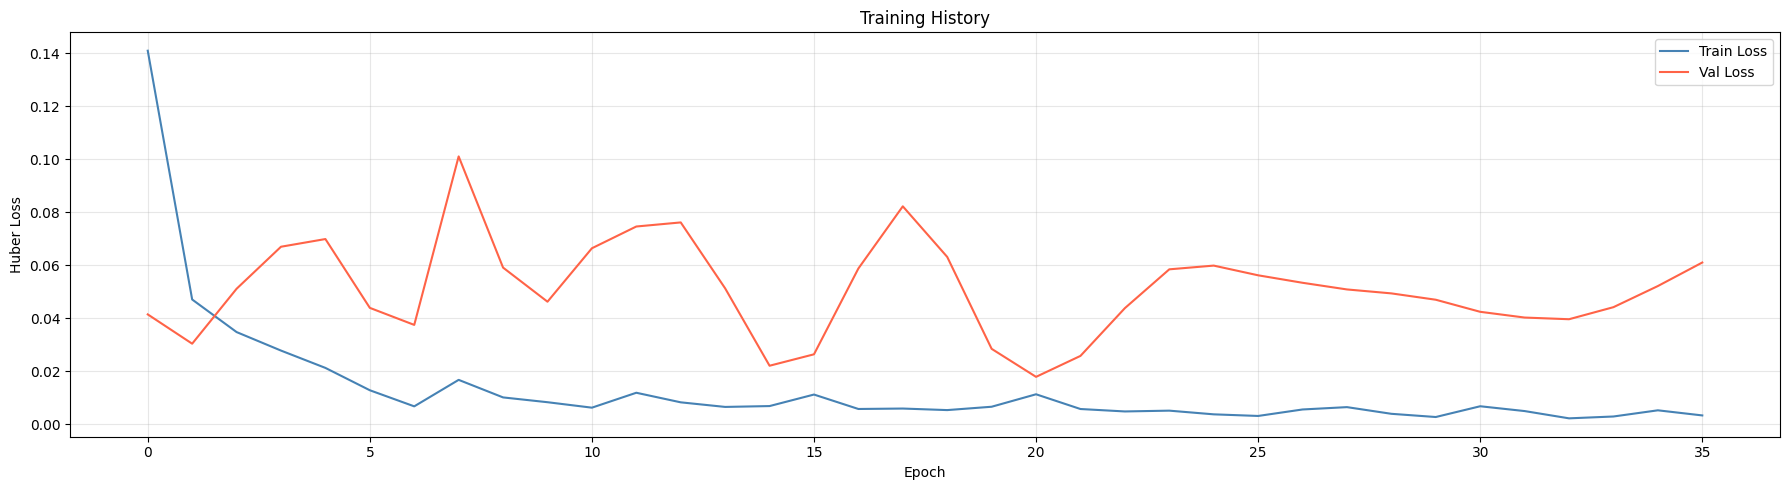

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))


plt.plot(train_losses, label='Train Loss', color='steelblue')
plt.plot(val_losses,   label='Val Loss',   color='tomato')
plt.title('Training History')
plt.ylabel('Huber Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()